In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install timm -q

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageFilter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


In [ ]:
DATA_DIR = "/content/drive/MyDrive/C-NMC/C-NMC_training_data"

SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32
IMG_PER_CLASS_PER_FOLD = 1000

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [ ]:
all_data = []

valid_ext = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

for fold in ["fold_0", "fold_1", "fold_2"]:

    for class_name, label in [("all", 1), ("hem", 0)]:

        folder = os.path.join(DATA_DIR, fold, class_name)

        images = [
            os.path.join(folder, f)
            for f in os.listdir(folder)
            if f.lower().endswith(valid_ext)
        ]

        print(f"{fold} - {class_name}: {len(images)} images")

        selected_images = random.sample(
            images,
            IMG_PER_CLASS_PER_FOLD
        )

        for img_path in selected_images:
            all_data.append({
                "image_path": img_path,
                "label": label,
                "class_name": class_name,
                "fold": fold
            })

df = pd.DataFrame(all_data)

print("\nFinal balanced dataset:")
print(df["class_name"].value_counts())
print(df.shape)

fold_0 - all: 2397 images
fold_0 - hem: 1130 images
fold_1 - all: 2418 images
fold_1 - hem: 1163 images
fold_2 - all: 2457 images
fold_2 - hem: 1096 images

Final balanced dataset:
class_name
all    3000
hem    3000
Name: count, dtype: int64
(6000, 4)


In [ ]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print("Train:", train_df.shape)
print(train_df["class_name"].value_counts())

print("\nValidation:", val_df.shape)
print(val_df["class_name"].value_counts())

print("\nTest:", test_df.shape)
print(test_df["class_name"].value_counts())

Train: (4200, 4)
class_name
all    2100
hem    2100
Name: count, dtype: int64

Validation: (900, 4)
class_name
hem    450
all    450
Name: count, dtype: int64

Test: (900, 4)
class_name
all    450
hem    450
Name: count, dtype: int64


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

In [ ]:
class LeukemiaDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.loc[idx, "image_path"]
        label = self.dataframe.loc[idx, "label"]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

In [ ]:
train_dataset = LeukemiaDataset(train_df, transform=train_transform)
val_dataset = LeukemiaDataset(val_df, transform=test_transform)
test_dataset = LeukemiaDataset(test_df, transform=test_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

images, labels = next(iter(train_loader))

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))
print(images.shape)
print(labels.shape)
print(labels[:10])

Train batches: 132
Validation batches: 29
Test batches: 29
torch.Size([32, 3, 224, 224])
torch.Size([32])
tensor([1, 0, 1, 0, 1, 1, 1, 1, 0, 0])


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, is_hybrid=False):
    model.train()
    total_loss = 0

    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        if is_hybrid:
            outputs, _ = model(images)
        else:
            outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
def evaluate_model(model, loader, criterion, is_hybrid=False):
    model.eval()

    total_loss = 0
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            if is_hybrid:
                outputs, _ = model(images)
            else:
                outputs = model(images)

            loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)

            total_loss += loss.item()

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds)
    rec = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)

    return (
        total_loss / len(loader),
        acc,
        prec,
        rec,
        f1,
        np.array(all_labels),
        np.array(all_preds),
        np.array(all_probs)
    )

In [ ]:
def plot_training_curves(history, model_name):
    plt.figure(figsize=(8,5))

    plt.plot(history["train_loss"], marker="o", label="Train Loss")
    plt.plot(history["val_loss"], marker="s", label="Validation Loss")

    plt.title(f"{model_name} - Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8,5))

    plt.plot(history["val_acc"], marker="o", label="Accuracy")
    plt.plot(history["val_precision"], marker="s", label="Precision")
    plt.plot(history["val_recall"], marker="^", label="Recall")
    plt.plot(history["val_f1"], marker="d", label="F1-score")

    plt.title(f"{model_name} - Validation Metrics")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_confusion_matrix(all_labels, all_preds, model_name, cmap="Blues"):
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(7,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=cmap,
        xticklabels=["HEM", "ALL"],
        yticklabels=["HEM", "ALL"],
        linewidths=1,
        linecolor="black",
        annot_kws={"size":16}
    )

    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

In [ ]:
class CustomCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
cnn_model = CustomCNN().to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    cnn_model.parameters(),
    lr=1e-4
)

EPOCHS = 10

history_cnn = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_precision": [],
    "val_recall": [],
    "val_f1": []
}

best_val_f1 = 0

for epoch in range(EPOCHS):

    train_loss = train_one_epoch(
        cnn_model,
        train_loader,
        optimizer,
        criterion
    )

    val_loss, val_acc, val_prec, val_rec, val_f1, _, _, _ = evaluate_model(
        cnn_model,
        val_loader,
        criterion
    )

    history_cnn["train_loss"].append(train_loss)
    history_cnn["val_loss"].append(val_loss)
    history_cnn["val_acc"].append(val_acc)
    history_cnn["val_precision"].append(val_prec)
    history_cnn["val_recall"].append(val_rec)
    history_cnn["val_f1"].append(val_f1)

    print(f"Epoch [{epoch+1}/{EPOCHS}]")
    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Acc: {val_acc:.4f} | "
        f"Precision: {val_prec:.4f} | "
        f"Recall: {val_rec:.4f} | "
        f"F1: {val_f1:.4f}"
    )
    print("-" * 60)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(cnn_model.state_dict(), "/content/best_custom_cnn.pth")
        print("Best Custom CNN saved!")

Epoch [1/10]
Train Loss: 0.5809 | Val Loss: 0.4930 | Acc: 0.7789 | Precision: 0.8010 | Recall: 0.7422 | F1: 0.7705
------------------------------------------------------------
Best Custom CNN saved!
Epoch [2/10]
Train Loss: 0.4992 | Val Loss: 0.4522 | Acc: 0.7956 | Precision: 0.7818 | Recall: 0.8200 | F1: 0.8004
------------------------------------------------------------
Best Custom CNN saved!
Epoch [3/10]
Train Loss: 0.4616 | Val Loss: 0.4807 | Acc: 0.7711 | Precision: 0.7027 | Recall: 0.9400 | F1: 0.8042
------------------------------------------------------------
Best Custom CNN saved!
Epoch [4/10]
Train Loss: 0.4371 | Val Loss: 0.4068 | Acc: 0.8289 | Precision: 0.8008 | Recall: 0.8756 | F1: 0.8365
------------------------------------------------------------
Best Custom CNN saved!
Epoch [5/10]
Train Loss: 0.4064 | Val Loss: 0.3847 | Acc: 0.8256 | Precision: 0.8234 | Recall: 0.8289 | F1: 0.8261
------------------------------------------------------------
Epoch [6/10]
Train Loss: 0.3

In [ ]:
cnn_model.load_state_dict(
    torch.load("/content/best_custom_cnn.pth")
)

cnn_model.eval()

test_loss, test_acc, test_prec, test_rec, test_f1, cnn_labels, cnn_preds, cnn_probs = evaluate_model(
    cnn_model,
    test_loader,
    criterion
)

print("Custom CNN Test Results")
print(f"Accuracy:  {test_acc:.4f}")
print(f"Precision: {test_prec:.4f}")
print(f"Recall:    {test_rec:.4f}")
print(f"F1-score:  {test_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        cnn_labels,
        cnn_preds,
        target_names=["HEM", "ALL"]
    )
)

Custom CNN Test Results
Accuracy:  0.8367
Precision: 0.7908
Recall:    0.9156
F1-score:  0.8486

Classification Report:
              precision    recall  f1-score   support

         HEM       0.90      0.76      0.82       450
         ALL       0.79      0.92      0.85       450

    accuracy                           0.84       900
   macro avg       0.85      0.84      0.84       900
weighted avg       0.85      0.84      0.84       900



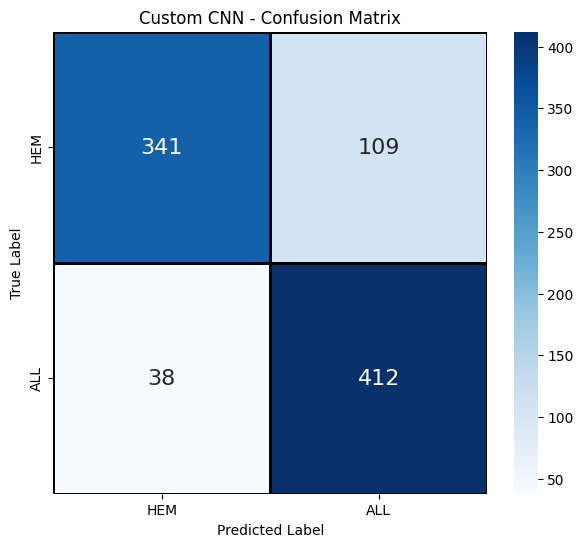

In [ ]:
plot_confusion_matrix(
    cnn_labels,
    cnn_preds,
    "Custom CNN",
    cmap="Blues"
)

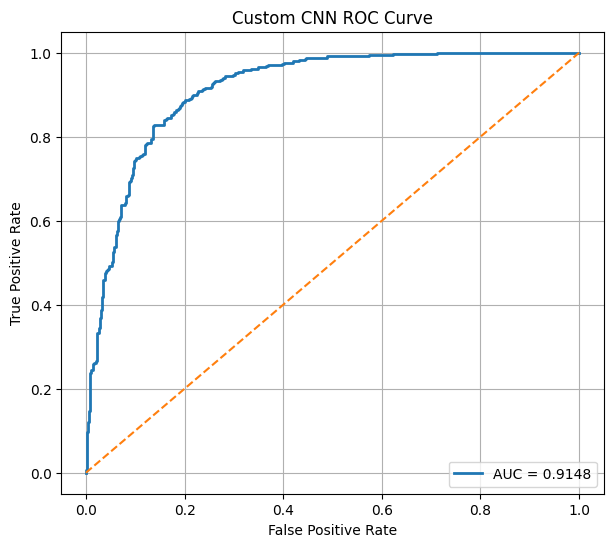

CNN AUC: 0.9147901234567901


In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(cnn_labels, cnn_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'AUC = {roc_auc:.4f}'
)

plt.plot([0,1], [0,1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Custom CNN ROC Curve")

plt.legend(loc="lower right")
plt.grid(True)

plt.show()

print("CNN AUC:", roc_auc)

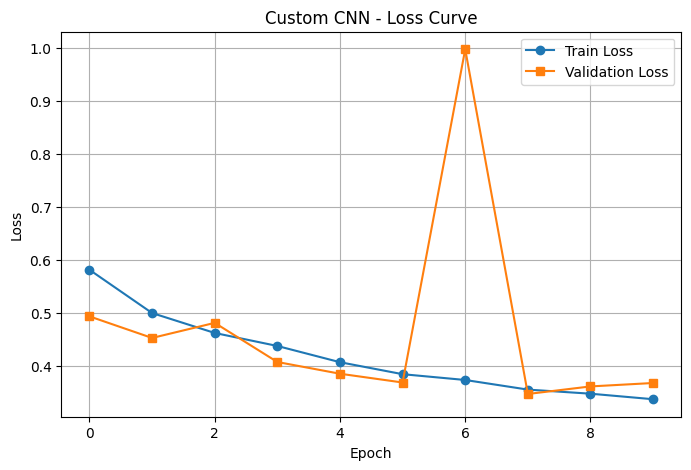

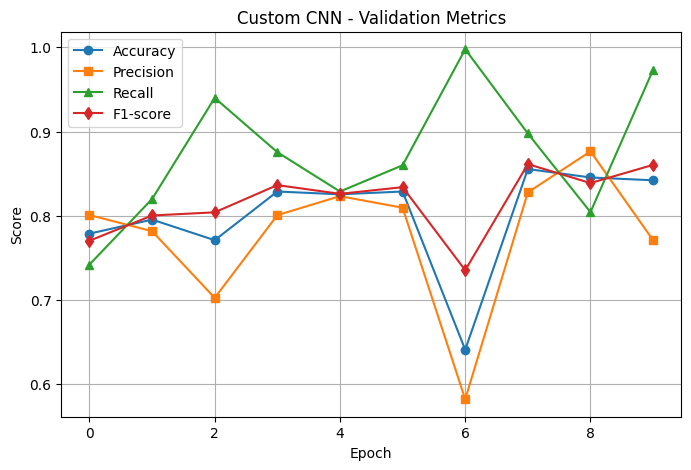

In [ ]:
plot_training_curves(
    history_cnn,
    "Custom CNN"
)

In [ ]:
cnn_acc = test_acc
cnn_prec = test_prec
cnn_rec = test_rec
cnn_f1 = test_f1

In [ ]:
mobilenet_model = timm.create_model(
    "mobilenetv2_100",
    pretrained=True,
    num_classes=2
).to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    mobilenet_model.parameters(),
    lr=1e-4
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/14.2M [00:00<?, ?B/s]

In [ ]:
EPOCHS = 10

history_mobilenet = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_precision": [],
    "val_recall": [],
    "val_f1": []
}

best_val_f1 = 0

for epoch in range(EPOCHS):

    train_loss = train_one_epoch(
        mobilenet_model,
        train_loader,
        optimizer,
        criterion
    )

    val_loss, val_acc, val_prec, val_rec, val_f1, _, _, _ = evaluate_model(
        mobilenet_model,
        val_loader,
        criterion
    )

    history_mobilenet["train_loss"].append(train_loss)
    history_mobilenet["val_loss"].append(val_loss)
    history_mobilenet["val_acc"].append(val_acc)
    history_mobilenet["val_precision"].append(val_prec)
    history_mobilenet["val_recall"].append(val_rec)
    history_mobilenet["val_f1"].append(val_f1)

    print(f"Epoch [{epoch+1}/{EPOCHS}]")
    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Acc: {val_acc:.4f} | "
        f"Precision: {val_prec:.4f} | "
        f"Recall: {val_rec:.4f} | "
        f"F1: {val_f1:.4f}"
    )
    print("-" * 60)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(mobilenet_model.state_dict(), "/content/best_mobilenetv2.pth")
        print("Best MobileNetV2 saved!")

Epoch [1/10]
Train Loss: 0.1346 | Val Loss: 1.1089 | Acc: 0.6433 | Precision: 0.9006 | Recall: 0.3222 | F1: 0.4746
------------------------------------------------------------
Best MobileNetV2 saved!
Epoch [2/10]
Train Loss: 0.1338 | Val Loss: 0.7264 | Acc: 0.7089 | Precision: 0.8821 | Recall: 0.4822 | F1: 0.6236
------------------------------------------------------------
Best MobileNetV2 saved!
Epoch [3/10]
Train Loss: 0.1234 | Val Loss: 0.4576 | Acc: 0.8544 | Precision: 0.7905 | Recall: 0.9644 | F1: 0.8689
------------------------------------------------------------
Best MobileNetV2 saved!
Epoch [4/10]
Train Loss: 0.1050 | Val Loss: 0.4120 | Acc: 0.8578 | Precision: 0.8233 | Recall: 0.9111 | F1: 0.8650
------------------------------------------------------------
Epoch [5/10]
Train Loss: 0.1131 | Val Loss: 0.4299 | Acc: 0.8344 | Precision: 0.8352 | Recall: 0.8333 | F1: 0.8343
------------------------------------------------------------
Epoch [6/10]
Train Loss: 0.1037 | Val Loss: 0.38

In [ ]:
mobilenet_model.load_state_dict(
    torch.load("/content/best_mobilenetv2.pth")
)

mobilenet_model.eval()

test_loss, test_acc, test_prec, test_rec, test_f1, mobilenet_labels, mobilenet_preds, mobilenet_probs = evaluate_model(
    mobilenet_model,
    test_loader,
    criterion
)

print("MobileNetV2 Test Results")
print(f"Accuracy:  {test_acc:.4f}")
print(f"Precision: {test_prec:.4f}")
print(f"Recall:    {test_rec:.4f}")
print(f"F1-score:  {test_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        mobilenet_labels,
        mobilenet_preds,
        target_names=["HEM", "ALL"]
    )
)

MobileNetV2 Test Results
Accuracy:  0.8767
Precision: 0.8509
Recall:    0.9133
F1-score:  0.8810

Classification Report:
              precision    recall  f1-score   support

         HEM       0.91      0.84      0.87       450
         ALL       0.85      0.91      0.88       450

    accuracy                           0.88       900
   macro avg       0.88      0.88      0.88       900
weighted avg       0.88      0.88      0.88       900



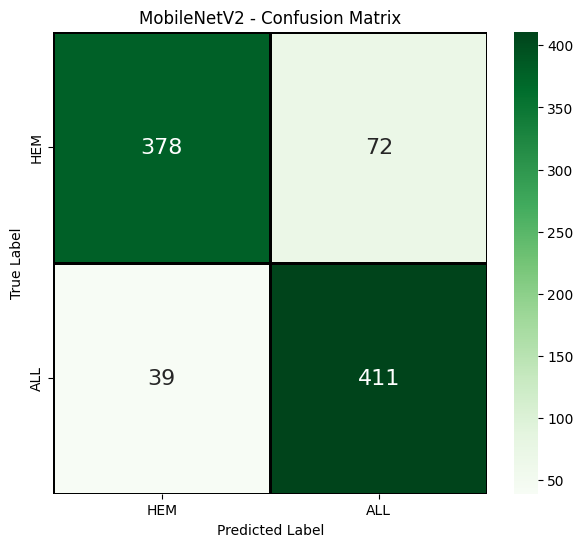

In [ ]:
plot_confusion_matrix(
    mobilenet_labels,
    mobilenet_preds,
    "MobileNetV2",
    cmap="Greens"
)

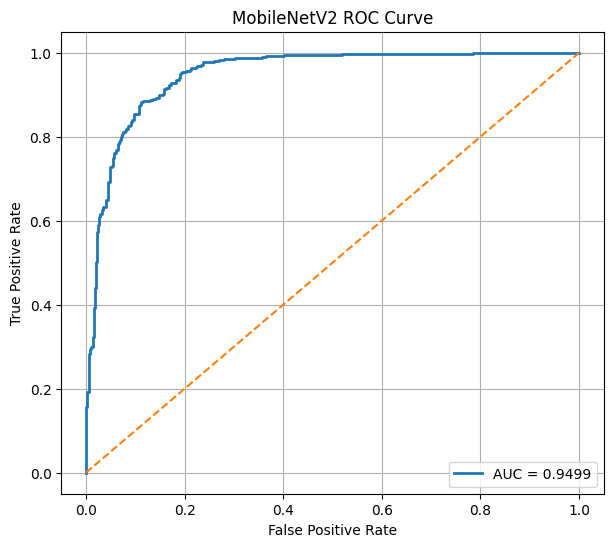

In [ ]:
fpr, tpr, _ = roc_curve(mobilenet_labels, mobilenet_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, linewidth=2,
         label=f'AUC = {roc_auc:.4f}')

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("MobileNetV2 ROC Curve")

plt.legend()
plt.grid(True)

plt.show()

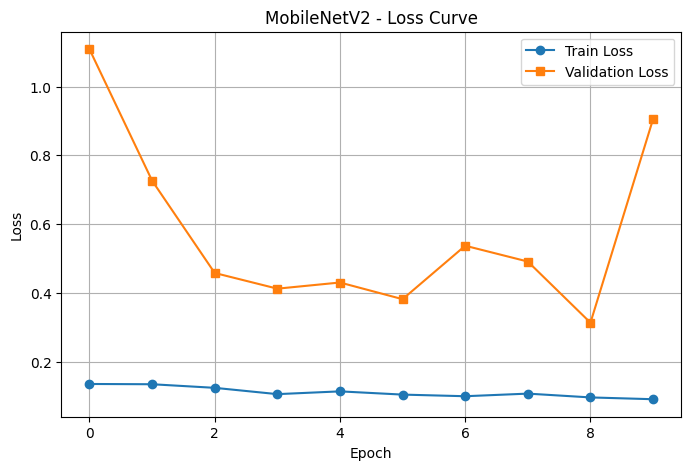

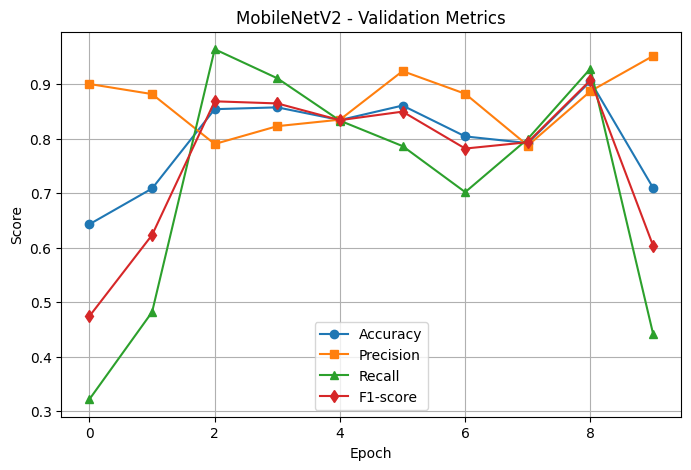

In [ ]:
plot_training_curves(
    history_mobilenet,
    "MobileNetV2"
)

In [ ]:
mobilenet_acc = test_acc
mobilenet_prec = test_prec
mobilenet_rec = test_rec
mobilenet_f1 = test_f1

In [ ]:
efficientnet_model = timm.create_model(
    "efficientnet_b0",
    pretrained=True,
    num_classes=2
).to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    efficientnet_model.parameters(),
    lr=1e-4
)

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

In [ ]:
EPOCHS = 10

history_efficientnet = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_precision": [],
    "val_recall": [],
    "val_f1": []
}

best_val_f1 = 0

for epoch in range(EPOCHS):

    train_loss = train_one_epoch(
        efficientnet_model,
        train_loader,
        optimizer,
        criterion
    )

    val_loss, val_acc, val_prec, val_rec, val_f1, _, _, _ = evaluate_model(
        efficientnet_model,
        val_loader,
        criterion
    )

    history_efficientnet["train_loss"].append(train_loss)
    history_efficientnet["val_loss"].append(val_loss)
    history_efficientnet["val_acc"].append(val_acc)
    history_efficientnet["val_precision"].append(val_prec)
    history_efficientnet["val_recall"].append(val_rec)
    history_efficientnet["val_f1"].append(val_f1)

    print(f"Epoch [{epoch+1}/{EPOCHS}]")
    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Acc: {val_acc:.4f} | "
        f"Precision: {val_prec:.4f} | "
        f"Recall: {val_rec:.4f} | "
        f"F1: {val_f1:.4f}"
    )
    print("-" * 60)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(
            efficientnet_model.state_dict(),
            "/content/best_efficientnetb0.pth"
        )
        print("Best EfficientNetB0 saved!")

Epoch [1/10]
Train Loss: 0.0943 | Val Loss: 0.9100 | Acc: 0.8033 | Precision: 0.7271 | Recall: 0.9711 | F1: 0.8316
------------------------------------------------------------
Best EfficientNetB0 saved!
Epoch [2/10]
Train Loss: 0.1034 | Val Loss: 0.6518 | Acc: 0.7889 | Precision: 0.7519 | Recall: 0.8622 | F1: 0.8033
------------------------------------------------------------
Epoch [3/10]
Train Loss: 0.1011 | Val Loss: 0.3072 | Acc: 0.9244 | Precision: 0.9226 | Recall: 0.9267 | F1: 0.9246
------------------------------------------------------------
Best EfficientNetB0 saved!
Epoch [4/10]
Train Loss: 0.0818 | Val Loss: 1.1915 | Acc: 0.7144 | Precision: 0.9367 | Recall: 0.4600 | F1: 0.6170
------------------------------------------------------------
Epoch [5/10]
Train Loss: 0.0899 | Val Loss: 0.8378 | Acc: 0.7356 | Precision: 0.9344 | Recall: 0.5067 | F1: 0.6571
------------------------------------------------------------
Epoch [6/10]
Train Loss: 0.1035 | Val Loss: 0.3024 | Acc: 0.9189 |

In [ ]:
efficientnet_model.load_state_dict(
    torch.load("/content/best_efficientnetb0.pth")
)

efficientnet_model.eval()

test_loss, test_acc, test_prec, test_rec, test_f1, efficientnet_labels, efficientnet_preds, efficientnet_probs = evaluate_model(
    efficientnet_model,
    test_loader,
    criterion
)

print("EfficientNetB0 Test Results")
print(f"Accuracy:  {test_acc:.4f}")
print(f"Precision: {test_prec:.4f}")
print(f"Recall:    {test_rec:.4f}")
print(f"F1-score:  {test_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        efficientnet_labels,
        efficientnet_preds,
        target_names=["HEM", "ALL"]
    )
)

EfficientNetB0 Test Results
Accuracy:  0.8744
Precision: 0.8547
Recall:    0.9022
F1-score:  0.8778

Classification Report:
              precision    recall  f1-score   support

         HEM       0.90      0.85      0.87       450
         ALL       0.85      0.90      0.88       450

    accuracy                           0.87       900
   macro avg       0.88      0.87      0.87       900
weighted avg       0.88      0.87      0.87       900



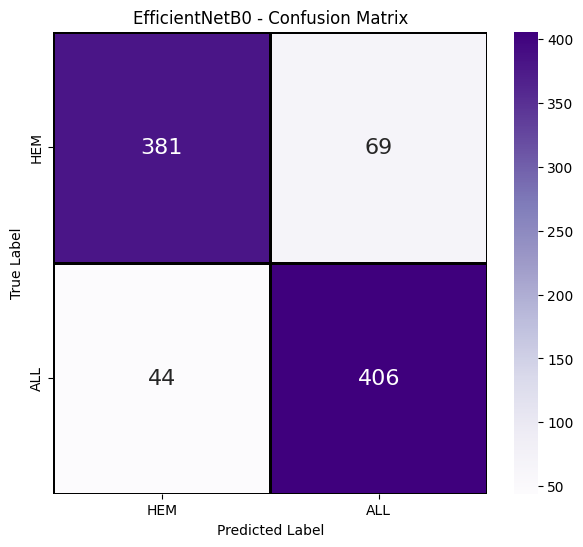

In [ ]:
plot_confusion_matrix(
    efficientnet_labels,
    efficientnet_preds,
    "EfficientNetB0",
    cmap="Purples"
)

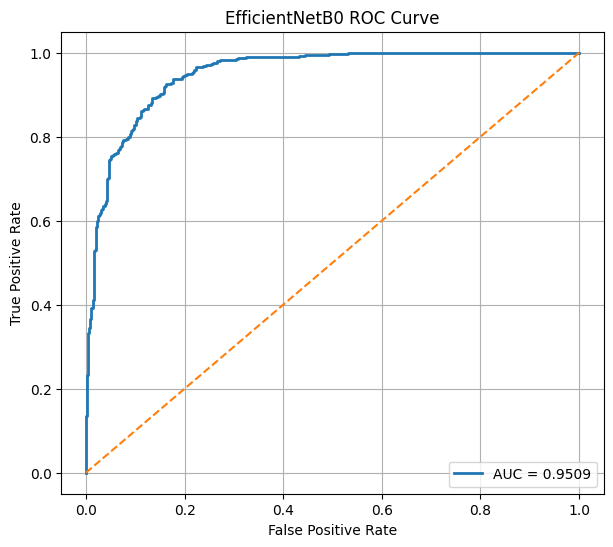

In [ ]:
fpr, tpr, _ = roc_curve(
    efficientnet_labels,
    efficientnet_probs
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'AUC = {roc_auc:.4f}'
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("EfficientNetB0 ROC Curve")

plt.legend()
plt.grid(True)

plt.show()

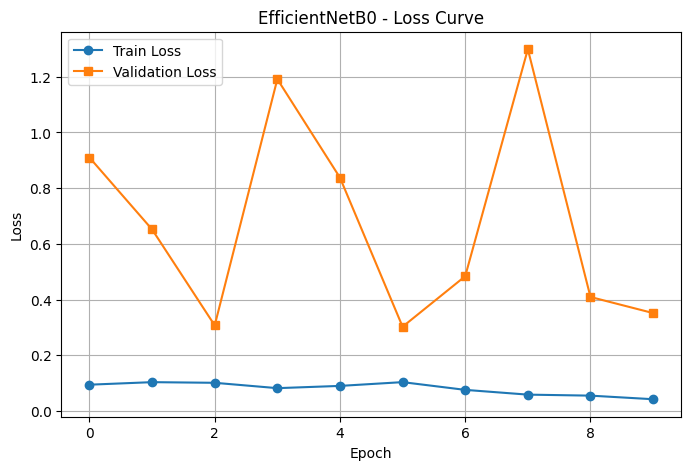

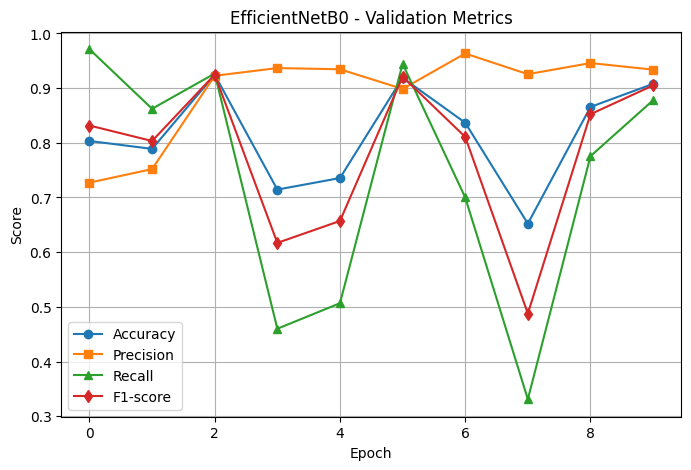

In [ ]:
plot_training_curves(
    history_efficientnet,
    "EfficientNetB0"
)

In [ ]:
efficientnet_acc = test_acc
efficientnet_prec = test_prec
efficientnet_rec = test_rec
efficientnet_f1 = test_f1

In [ ]:
vit_model = timm.create_model(
    "vit_tiny_patch16_224",
    pretrained=True,
    num_classes=2
).to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    vit_model.parameters(),
    lr=1e-5

In [ ]:
EPOCHS = 10

history_vit = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_precision": [],
    "val_recall": [],
    "val_f1": []
}

best_val_f1 = 0

for epoch in range(EPOCHS):

    train_loss = train_one_epoch(
        vit_model,
        train_loader,
        optimizer,
        criterion
    )

    val_loss, val_acc, val_prec, val_rec, val_f1, _, _, _ = evaluate_model(
        vit_model,
        val_loader,
        criterion
    )

    history_vit["train_loss"].append(train_loss)
    history_vit["val_loss"].append(val_loss)
    history_vit["val_acc"].append(val_acc)
    history_vit["val_precision"].append(val_prec)
    history_vit["val_recall"].append(val_rec)
    history_vit["val_f1"].append(val_f1)

    print(f"Epoch [{epoch+1}/{EPOCHS}]")
    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Acc: {val_acc:.4f} | "
        f"Precision: {val_prec:.4f} | "
        f"Recall: {val_rec:.4f} | "
        f"F1: {val_f1:.4f}"
    )
    print("-" * 60)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(
            vit_model.state_dict(),
            "/content/best_vit.pth"
        )
        print("Best ViT saved!")

Epoch [1/10]
Train Loss: 0.1532 | Val Loss: 0.2622 | Acc: 0.8922 | Precision: 0.9039 | Recall: 0.8778 | F1: 0.8906
------------------------------------------------------------
Best ViT saved!
Epoch [2/10]
Train Loss: 0.1427 | Val Loss: 0.2905 | Acc: 0.8867 | Precision: 0.9416 | Recall: 0.8244 | F1: 0.8791
------------------------------------------------------------
Epoch [3/10]
Train Loss: 0.1354 | Val Loss: 0.3965 | Acc: 0.8444 | Precision: 0.9454 | Recall: 0.7311 | F1: 0.8246
------------------------------------------------------------
Epoch [4/10]
Train Loss: 0.1229 | Val Loss: 0.2869 | Acc: 0.9011 | Precision: 0.9392 | Recall: 0.8578 | F1: 0.8966
------------------------------------------------------------
Best ViT saved!
Epoch [5/10]
Train Loss: 0.1043 | Val Loss: 0.4173 | Acc: 0.8556 | Precision: 0.9598 | Recall: 0.7422 | F1: 0.8371
------------------------------------------------------------
Epoch [6/10]
Train Loss: 0.0935 | Val Loss: 0.3944 | Acc: 0.8578 | Precision: 0.9548 | R

In [ ]:
vit_model.load_state_dict(
    torch.load("/content/best_vit.pth")
)

vit_model.eval()

test_loss, test_acc, test_prec, test_rec, test_f1, vit_labels, vit_preds, vit_probs = evaluate_model(
    vit_model,
    test_loader,
    criterion
)

print("ViT Test Results")
print(f"Accuracy:  {test_acc:.4f}")
print(f"Precision: {test_prec:.4f}")
print(f"Recall:    {test_rec:.4f}")
print(f"F1-score:  {test_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        vit_labels,
        vit_preds,
        target_names=["HEM", "ALL"]
    )
)

ViT Test Results
Accuracy:  0.8967
Precision: 0.8507
Recall:    0.9622
F1-score:  0.9030

Classification Report:
              precision    recall  f1-score   support

         HEM       0.96      0.83      0.89       450
         ALL       0.85      0.96      0.90       450

    accuracy                           0.90       900
   macro avg       0.90      0.90      0.90       900
weighted avg       0.90      0.90      0.90       900



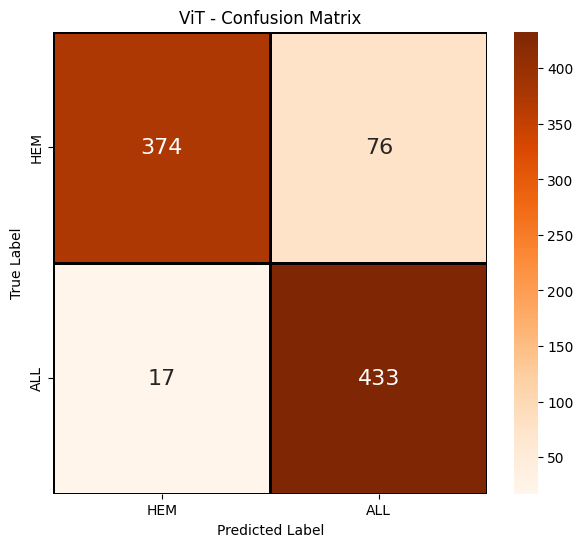

In [ ]:
plot_confusion_matrix(
    vit_labels,
    vit_preds,
    "ViT",
    cmap="Oranges"
)

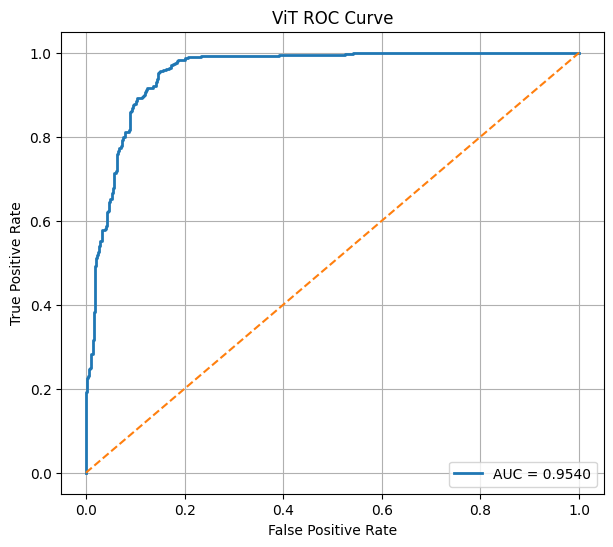

In [ ]:
fpr, tpr, _ = roc_curve(vit_labels, vit_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'AUC = {roc_auc:.4f}'
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ViT ROC Curve")

plt.legend()
plt.grid(True)

plt.show()

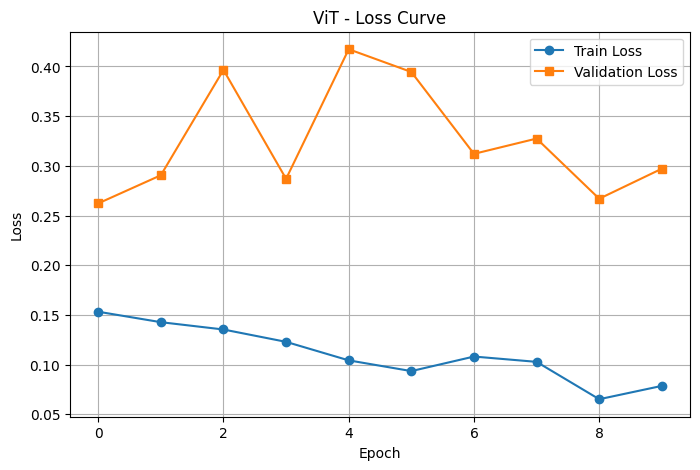

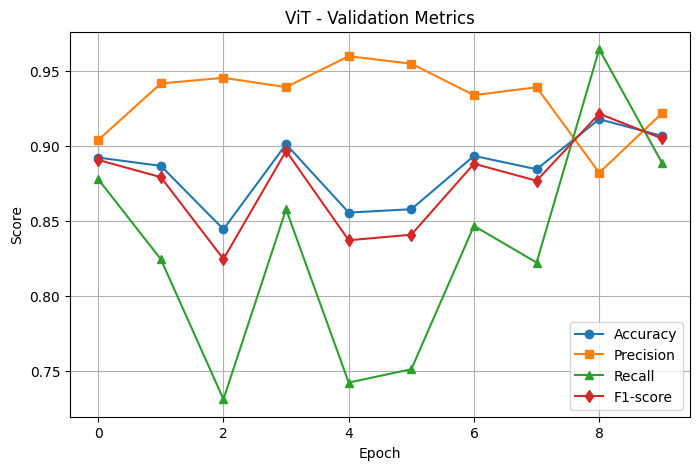

In [ ]:
plot_training_curves(
    history_vit,
    "ViT"
)

In [ ]:
class AttentionFusion(nn.Module):
    def __init__(self, feature_dim):
        super().__init__()

        self.attention = nn.Sequential(
            nn.Linear(feature_dim * 2, feature_dim),
            nn.ReLU(),
            nn.Linear(feature_dim, 2),
            nn.Softmax(dim=1)
        )

    def forward(self, eff_features, vit_features):
        combined = torch.cat([eff_features, vit_features], dim=1)

        weights = self.attention(combined)

        eff_weight = weights[:, 0].unsqueeze(1)
        vit_weight = weights[:, 1].unsqueeze(1)

        fused_features = (
            eff_weight * eff_features +
            vit_weight * vit_features
        )

        return fused_features, weights

In [ ]:
class HybridEfficientNetViT(nn.Module):
    def __init__(self, num_classes=2, feature_dim=512):
        super().__init__()

        self.efficientnet = timm.create_model(
            "efficientnet_b0",
            pretrained=True,
            num_classes=0
        )

        self.vit = timm.create_model(
            "vit_tiny_patch16_224",
            pretrained=True,
            num_classes=0
        )

        self.eff_projection = nn.Linear(
            self.efficientnet.num_features,
            feature_dim
        )

        self.vit_projection = nn.Linear(
            self.vit.num_features,
            feature_dim
        )

        self.fusion = AttentionFusion(feature_dim)

        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(feature_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        eff_features = self.efficientnet(x)
        vit_features = self.vit(x)

        eff_features = self.eff_projection(eff_features)
        vit_features = self.vit_projection(vit_features)

        fused_features, attention_weights = self.fusion(
            eff_features,
            vit_features
        )

        outputs = self.classifier(fused_features)

        return outputs, attention_weights

In [ ]:
hybrid_model = HybridEfficientNetViT().to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    hybrid_model.parameters(),
    lr=1e-5
)

EPOCHS = 10

history_hybrid = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_precision": [],
    "val_recall": [],
    "val_f1": [],
    "eff_attention": [],
    "vit_attention": []
}

best_val_f1 = 0

for epoch in range(EPOCHS):

    train_loss = train_one_epoch(
        hybrid_model,
        train_loader,
        optimizer,
        criterion,
        is_hybrid=True
    )

    val_loss, val_acc, val_prec, val_rec, val_f1, _, _, _ = evaluate_model(
        hybrid_model,
        val_loader,
        criterion,
        is_hybrid=True
    )

    # Attention weights on one validation batch
    hybrid_model.eval()
    with torch.no_grad():
        sample_images, _ = next(iter(val_loader))
        sample_images = sample_images.to(DEVICE)
        _, attention_weights = hybrid_model(sample_images)

        mean_eff_attention = attention_weights[:, 0].mean().item()
        mean_vit_attention = attention_weights[:, 1].mean().item()

    history_hybrid["train_loss"].append(train_loss)
    history_hybrid["val_loss"].append(val_loss)
    history_hybrid["val_acc"].append(val_acc)
    history_hybrid["val_precision"].append(val_prec)
    history_hybrid["val_recall"].append(val_rec)
    history_hybrid["val_f1"].append(val_f1)
    history_hybrid["eff_attention"].append(mean_eff_attention)
    history_hybrid["vit_attention"].append(mean_vit_attention)

    print(f"Epoch [{epoch+1}/{EPOCHS}]")
    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Acc: {val_acc:.4f} | "
        f"Precision: {val_prec:.4f} | "
        f"Recall: {val_rec:.4f} | "
        f"F1: {val_f1:.4f}"
    )

    print(
        f"Attention -> EfficientNet: {mean_eff_attention:.4f} | "
        f"ViT: {mean_vit_attention:.4f}"
    )

    print("-" * 60)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(
            hybrid_model.state_dict(),
            "/content/best_hybrid_efficientnet_vit_attention.pth"
        )
        print("Best Hybrid model saved!")

Epoch [1/10]
Train Loss: 0.5571 | Val Loss: 0.4773 | Acc: 0.7900 | Precision: 0.7933 | Recall: 0.7844 | F1: 0.7888
Attention -> EfficientNet: 0.4684 | ViT: 0.5316
------------------------------------------------------------
Best Hybrid model saved!
Epoch [2/10]
Train Loss: 0.4245 | Val Loss: 0.3723 | Acc: 0.8478 | Precision: 0.8075 | Recall: 0.9133 | F1: 0.8571
Attention -> EfficientNet: 0.4904 | ViT: 0.5096
------------------------------------------------------------
Best Hybrid model saved!
Epoch [3/10]
Train Loss: 0.3669 | Val Loss: 0.3371 | Acc: 0.8656 | Precision: 0.8799 | Recall: 0.8467 | F1: 0.8630
Attention -> EfficientNet: 0.5018 | ViT: 0.4982
------------------------------------------------------------
Best Hybrid model saved!
Epoch [4/10]
Train Loss: 0.3209 | Val Loss: 0.2969 | Acc: 0.8878 | Precision: 0.8628 | Recall: 0.9222 | F1: 0.8915
Attention -> EfficientNet: 0.4921 | ViT: 0.5079
------------------------------------------------------------
Best Hybrid model saved!
Epoc

In [ ]:
hybrid_model.load_state_dict(
    torch.load("/content/best_hybrid_efficientnet_vit_attention.pth")
)

hybrid_model.eval()

test_loss, test_acc, test_prec, test_rec, test_f1, hybrid_labels, hybrid_preds, hybrid_probs = evaluate_model(
    hybrid_model,
    test_loader,
    criterion,
    is_hybrid=True
)

print("Hybrid EfficientNet-ViT Attention Test Results")
print(f"Accuracy:  {test_acc:.4f}")
print(f"Precision: {test_prec:.4f}")
print(f"Recall:    {test_rec:.4f}")
print(f"F1-score:  {test_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        hybrid_labels,
        hybrid_preds,
        target_names=["HEM", "ALL"]
    )
)

Hybrid EfficientNet-ViT Attention Test Results
Accuracy:  0.9033
Precision: 0.8972
Recall:    0.9111
F1-score:  0.9041

Classification Report:
              precision    recall  f1-score   support

         HEM       0.91      0.90      0.90       450
         ALL       0.90      0.91      0.90       450

    accuracy                           0.90       900
   macro avg       0.90      0.90      0.90       900
weighted avg       0.90      0.90      0.90       900



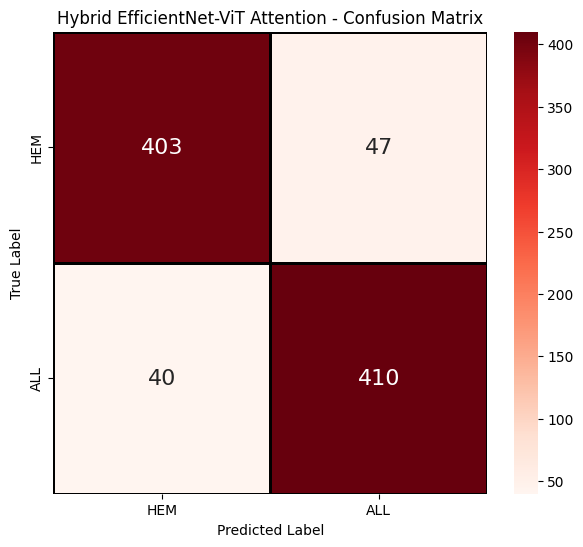

In [ ]:
plot_confusion_matrix(
    hybrid_labels,
    hybrid_preds,
    "Hybrid EfficientNet-ViT Attention",
    cmap="Reds"
)

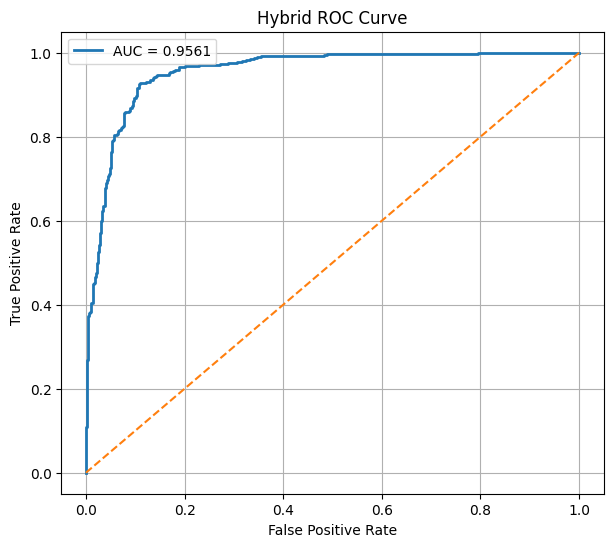

In [ ]:
fpr, tpr, _ = roc_curve(
    hybrid_labels,
    hybrid_probs
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'AUC = {roc_auc:.4f}'
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Hybrid ROC Curve")

plt.legend()
plt.grid(True)

plt.show()

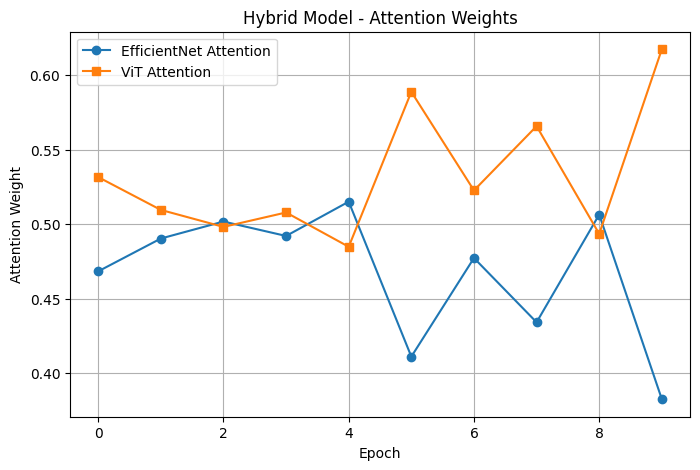

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history_hybrid["eff_attention"],
    marker="o",
    label="EfficientNet Attention"
)

plt.plot(
    history_hybrid["vit_attention"],
    marker="s",
    label="ViT Attention"
)

plt.title("Hybrid Model - Attention Weights")
plt.xlabel("Epoch")
plt.ylabel("Attention Weight")
plt.legend()
plt.grid(True)
plt.show()

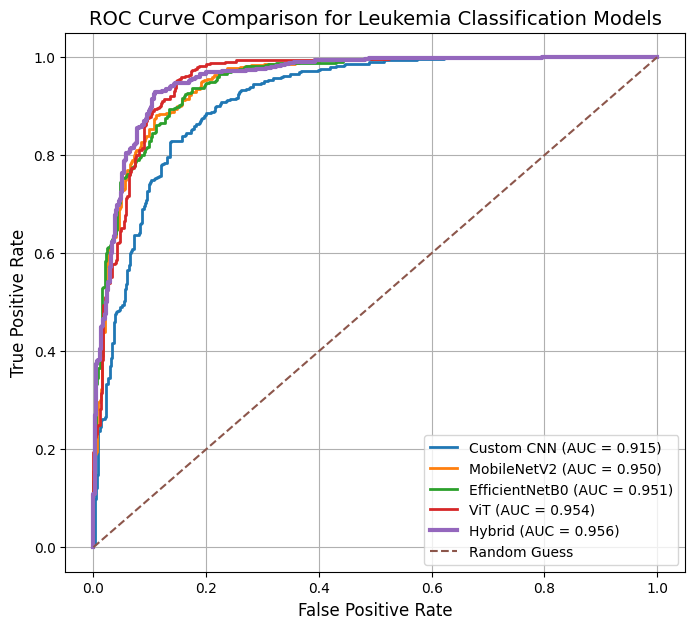

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8,7))

# =========================
# Custom CNN
# =========================
fpr, tpr, _ = roc_curve(cnn_labels, cnn_probs)
cnn_auc = auc(fpr, tpr)

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Custom CNN (AUC = {cnn_auc:.3f})"
)

# =========================
# MobileNetV2
# =========================
fpr, tpr, _ = roc_curve(
    mobilenet_labels,
    mobilenet_probs
)

mobilenet_auc = auc(fpr, tpr)

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"MobileNetV2 (AUC = {mobilenet_auc:.3f})"
)

# =========================
# EfficientNetB0
# =========================
fpr, tpr, _ = roc_curve(
    efficientnet_labels,
    efficientnet_probs
)

efficientnet_auc = auc(fpr, tpr)

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"EfficientNetB0 (AUC = {efficientnet_auc:.3f})"
)

# =========================
# ViT
# =========================
fpr, tpr, _ = roc_curve(
    vit_labels,
    vit_probs
)

vit_auc = auc(fpr, tpr)

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"ViT (AUC = {vit_auc:.3f})"
)

# =========================
# Hybrid
# =========================
fpr, tpr, _ = roc_curve(
    hybrid_labels,
    hybrid_probs
)

hybrid_auc = auc(fpr, tpr)

plt.plot(
    fpr,
    tpr,
    linewidth=3,
    label=f"Hybrid (AUC = {hybrid_auc:.3f})"
)

# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Guess"
)

plt.title("ROC Curve Comparison for Leukemia Classification Models",
          fontsize=14)

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

In [ ]:
results = [
    {
        "Model": "Custom CNN",
        "Accuracy": 0.8367,
        "Precision": 0.7908,
        "Recall": 0.9156,
        "F1-score": 0.8486
    },
    {
        "Model": "MobileNetV2",
        "Accuracy": 0.8767,
        "Precision": 0.8509,
        "Recall": 0.9133,
        "F1-score": 0.8810
    },
    {
        "Model": "EfficientNetB0",
        "Accuracy": 0.8744,
        "Precision": 0.8547,
        "Recall": 0.9022,
        "F1-score": 0.8778
    },
    {
        "Model": "ViT",
        "Accuracy": 0.8967,
        "Precision": 0.8507,
        "Recall": 0.9622,
        "F1-score": 0.9030
    },
    {
        "Model": "Hybrid EfficientNet-ViT Attention",
        "Accuracy": 0.9033,
        "Precision": 0.8972,
        "Recall": 0.9111,
        "F1-score": 0.9041
    }
]

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Custom CNN,0.8367,0.7908,0.9156,0.8486
1,MobileNetV2,0.8767,0.8509,0.9133,0.8810
2,EfficientNetB0,0.8744,0.8547,0.9022,0.8778
3,ViT,0.8967,0.8507,0.9622,0.9030
4,Hybrid EfficientNet-ViT Attention,0.9033,0.8972,0.9111,0.9041


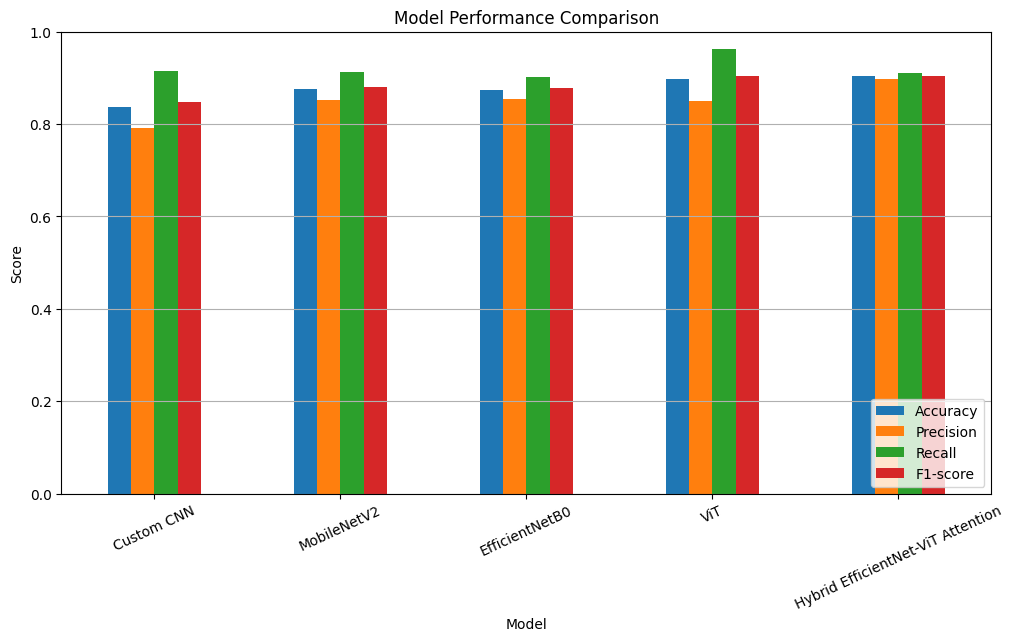

In [ ]:
results_df.set_index("Model")[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score"
]].plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=25)
plt.grid(axis="y")
plt.legend(loc="lower right")
plt.show()

In [ ]:
class LeukemiaRobustDataset(Dataset):
    def __init__(self, dataframe, degradation=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.degradation = degradation

        self.final_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(
                [0.485, 0.456, 0.406],
                [0.229, 0.224, 0.225]
            )
        ])

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.loc[idx, "image_path"]
        label = self.dataframe.loc[idx, "label"]

        image = Image.open(img_path).convert("RGB")

        if self.degradation is not None:
            image = self.degradation(image)

        image = self.final_transform(image)

        return image, torch.tensor(label, dtype=torch.long)

In [ ]:
class AddPILNoise:
    def __init__(self, std=10):
        self.std = std

    def __call__(self, img):
        arr = np.array(img).astype(np.float32)
        noise = np.random.normal(0, self.std, arr.shape)
        arr = np.clip(arr + noise, 0, 255).astype(np.uint8)
        return Image.fromarray(arr)


class LowResolutionPIL:
    def __init__(self, small_size=96, final_size=224):
        self.small_size = small_size
        self.final_size = final_size

    def __call__(self, img):
        img = img.resize((self.small_size, self.small_size))
        img = img.resize((self.final_size, self.final_size))
        return img

In [ ]:
clinical_degradations = {
    "Clean": None,

    "Blur": transforms.GaussianBlur(kernel_size=3),

    "Noise": AddPILNoise(std=8),

    "Brightness": transforms.ColorJitter(brightness=0.25),

    "Contrast": transforms.ColorJitter(contrast=0.25),

    "LowResolution": LowResolutionPIL(small_size=96)
}

In [ ]:
robustness_models = [
    {"Model": "Custom CNN", "model": cnn_model, "is_hybrid": False},
    {"Model": "MobileNetV2", "model": mobilenet_model, "is_hybrid": False},
    {"Model": "EfficientNetB0", "model": efficientnet_model, "is_hybrid": False},
    {"Model": "ViT", "model": vit_model, "is_hybrid": False},
    {"Model": "Hybrid", "model": hybrid_model, "is_hybrid": True}
]

robustness_results = []

for model_info in robustness_models:
    row = {"Model": model_info["Model"]}
    degraded_accs = []

    print("Testing:", model_info["Model"])

    for test_name, degradation in clinical_degradations.items():
        robust_dataset = LeukemiaRobustDataset(
            test_df,
            degradation=degradation
        )

        robust_loader = DataLoader(
            robust_dataset,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=2
        )

        acc = evaluate_accuracy_only(
            model_info["model"],
            robust_loader,
            is_hybrid=model_info["is_hybrid"]
        )

        row[test_name] = acc

        if test_name != "Clean":
            degraded_accs.append(acc)

    row["Robustness Score"] = np.mean(degraded_accs) / row["Clean"]

    robustness_results.append(row)

robustness_df = pd.DataFrame(robustness_results).round(4)
robustness_df

Testing: Custom CNN
Testing: MobileNetV2
Testing: EfficientNetB0
Testing: ViT
Testing: Hybrid


,Model,Clean,Blur,Noise,Brightness,Contrast,LowResolution,Robustness Score
0,Custom CNN,0.8367,0.8289,0.8156,0.8344,0.8411,0.7700,0.9777
1,MobileNetV2,0.8767,0.8778,0.6600,0.8711,0.8700,0.8033,0.9313
2,EfficientNetB0,0.8744,0.8756,0.5733,0.8700,0.8889,0.8256,0.9225
3,ViT,0.8967,0.8889,0.6856,0.8789,0.8767,0.8356,0.9291
4,Hybrid,0.9033,0.8878,0.8022,0.9011,0.8933,0.8322,0.9557


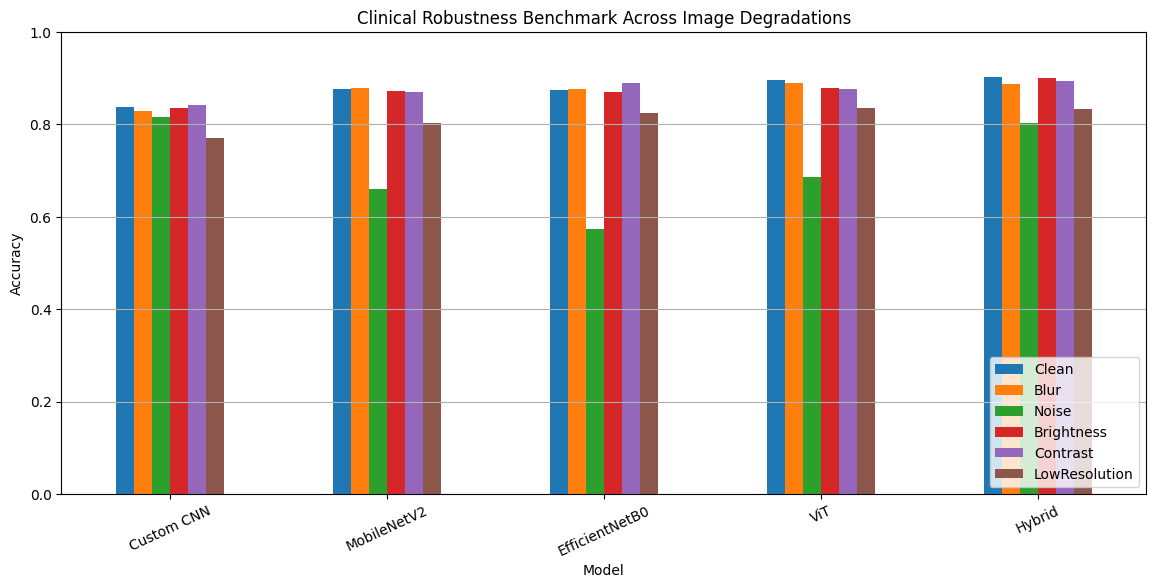

In [ ]:
robustness_df.set_index("Model")[
    [
        "Clean",
        "Blur",
        "Noise",
        "Brightness",
        "Contrast",
        "LowResolution"
    ]
].plot(
    kind="bar",
    figsize=(14,6)
)

plt.title("Clinical Robustness Benchmark Across Image Degradations")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.xticks(rotation=25)
plt.grid(axis="y")
plt.legend(loc="lower right")
plt.show()

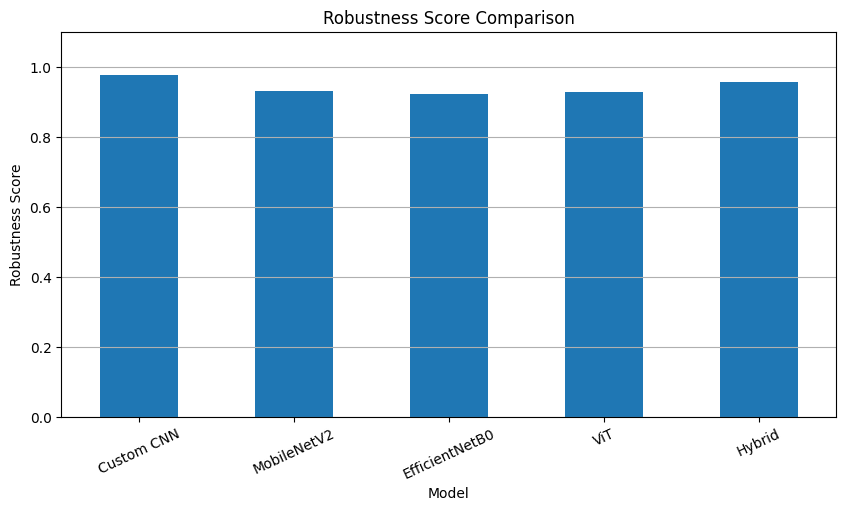

In [ ]:
robustness_df.set_index("Model")["Robustness Score"].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Robustness Score Comparison")
plt.ylabel("Robustness Score")
plt.ylim(0,1.1)
plt.xticks(rotation=25)
plt.grid(axis="y")
plt.show()